<p align="right">
  <img src="Zewail-City.png">
</p>


---

# __Problem set #4__

In [1]:
# Mian Libraries
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.polynomial.polynomial import polyfit
from scipy import fftpack
from scipy.stats import t, pearsonr, norm
from scipy.optimize import curve_fit
from scipy.signal import windows
from tqdm import trange
from IPython.display import Math, display

/home/hazem/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


### Problem 1: Mean CI by simulation

In [2]:
np.random.seed(42)

def t_confidence_interval(sample, alpha=0.05):
    """
    Compute two-sided (1-alpha) confidence interval for the mean using
    Student's t-distribution (sample assumed from an approximately normal pop).
    Returns (mean, lower, upper, half_width).
    """
    n = len(sample)
    mean = np.mean(sample)
    s = np.std(sample, ddof=1)           # sample standard deviation
    df = n - 1
    t_crit = t.ppf(1 - alpha/2, df)     # two-sided critical value
    half_width = t_crit * s / np.sqrt(n)
    return mean, mean - half_width, mean + half_width, half_width

In [3]:
n_list = [10, 20, 50, 100]
n_reps = 5000
alpha = 0.05
mu_true = 0.0
sigma_true = 1.0

results = []
coverage_by_n = {}
widths_by_n = {}

for n in n_list:
    contains = 0
    widths = []
    for _ in range(n_reps):
        sample = np.random.normal(loc=mu_true, scale=sigma_true, size=n)
        mean, lo, hi, hw = t_confidence_interval(sample, alpha=alpha)
        widths.append(2*hw)            # full interval width
        if (lo <= mu_true) and (mu_true <= hi):
            contains += 1
    coverage = contains / n_reps
    mean_width = np.mean(widths)
    std_width = np.std(widths, ddof=1)
    results.append((n, coverage, mean_width, std_width))
    coverage_by_n[n] = coverage
    widths_by_n[n] = (mean_width, std_width)

In [4]:
# Print a summary table
df = pd.DataFrame(results, columns=['n', 'Empirical coverage', 'Mean CI width', 'Std CI width'])
df['Empirical coverage (%)'] = df['Empirical coverage'] * 100
df = df[['n', 'Empirical coverage (%)', 'Mean CI width', 'Std CI width']]
df

,n,Empirical coverage (%),Mean CI width,Std CI width
0,10,95.22,1.391655,0.327013
1,20,94.58,0.923846,0.151984
2,50,95.04,0.565691,0.057183
3,100,94.54,0.395942,0.028571


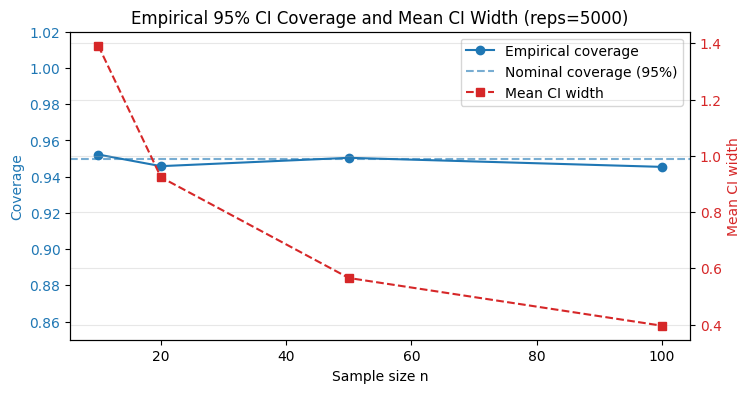

In [5]:
# Plot empirical coverage and mean CI width
fig, ax1 = plt.subplots(figsize=(8,4))

ns = list(coverage_by_n.keys())
coverage_vals = [coverage_by_n[n] for n in ns]
mean_widths = [widths_by_n[n][0] for n in ns]

ax1.plot(ns, coverage_vals, 'o-', label='Empirical coverage', color='tab:blue')
ax1.axhline(1-alpha, color='tab:blue', linestyle='--', alpha=0.6, label='Nominal coverage (95%)')
ax1.set_xlabel('Sample size n')
ax1.set_ylabel('Coverage', color='tab:blue')
ax1.set_ylim(0.85, 1.02)
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.plot(ns, mean_widths, 's--', color='tab:red', label='Mean CI width')
ax2.set_ylabel('Mean CI width', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper right')

plt.title(f'Empirical 95% CI Coverage and Mean CI Width (reps={n_reps})')
plt.grid(alpha=0.3)
plt.show()

### Discussion — convergence of empirical coverage to nominal 95%

- The table and plot above show the **empirical fraction of 95% confidence intervals that contain the true mean** for sample sizes $n=10,20,50,100$, each estimated from 5000 repetitions.
- For small $n$ (e.g. $n=10$) the empirical coverage may deviate somewhat from the nominal 95% due to sampling variability and heavier tails in finite samples; as $n$ increases, the empirical coverage moves closer to the nominal 95% value.
- The **mean CI width** decreases roughly like $1/\sqrt{n}$, so larger samples give narrower intervals (more precise estimates) while maintaining coverage.
- This behavior illustrates the Central Limit Theorem and the validity of the t-based interval for approximately normal data: with increasing $n$, the t-intervals provide coverage that converges to the nominal level and the uncertainty in the mean shrinks.


---

### Problem 2: Regression CI and experiment design

#### Analytical derivation 
For ordinary least-squares linear regression $y_i = m x_i + c + \epsilon_i$ with $\epsilon_i$ i.i.d. noise, $\mathbb{E}[\epsilon_i]=0$ and $\operatorname{Var}(\epsilon_i)=\sigma^2$, the variance of the slope estimator is

$$
\operatorname{Var}(\hat m) ;=; \frac{\sigma^2}{S_{xx}},
\qquad S_{xx}=\sum_{i=1}^n (x_i-\bar x)^2.
$$

If the $x_i$ are drawn uniformly on $[a,b]$ (or equally spaced across $[a,b]$, their population variance is

$$
\operatorname{Var}(x)=\frac{(b-a)^2}{12}.
$$

For ($n$) independent draws, $S_{xx}\approx n\operatorname{Var}(x)=n\frac{(b-a)^2}{12}$. Substitute into the formula:

$$
\boxed{\displaystyle \operatorname{Var}(\hat m)
\approx \frac{\sigma^2}{n\operatorname{Var}(x)}
= \frac{\sigma^2}{n,(b-a)^2/12}
= \frac{12,\sigma^2}{n (b-a)^2}.}
$$

Hence $\operatorname{Var}(\hat m)\propto 1/(b-a)^2$: **spreading the (x)-values over a wider interval decreases the variance of the slope estimator** (quadratically with interval width).


In [6]:
# Numerical illustration of Var(m_hat) vs interval width (b-a)

np.random.seed(0)

def linear(x, m, c):
    return m*x + c

# Settings
n = 30               # samples per experiment
sigma_noise = 2.0    # noise std dev (sigma)
n_trials = 2000      # number of repeated experiments for each width

widths = np.array([0.5, 1.0, 2.0, 5.0, 10.0])  # (b-a) values to test
m_estimates = {w: [] for w in widths}

for w in widths:
    a = -w/2.0     # use symmetric interval [-w/2, w/2]
    b =  w/2.0
    for _ in range(n_trials):
        x = np.random.uniform(a, b, size=n)
        # true line with m_true = 2.0, c_true = 1.0 (choice doesn't matter)
        y = 2.0 * x + 1.0 + np.random.normal(0, sigma_noise, size=n)
        # fit
        popt, pcov = curve_fit(linear, x, y, p0=[1.0, 0.0])
        m_estimates[w].append(popt[0])

# Compute empirical variances and theoretical predictions
emp_var = np.array([np.var(m_estimates[w], ddof=1) for w in widths])
theory_var = 12 * (sigma_noise**2) / (n * widths**2)
ratio = emp_var / theory_var

In [7]:
# Create DataFrame
df = pd.DataFrame({
    "Width (b - a)": widths,
    "Empirical Var(m̂)": emp_var,
    "Theoretical Var(m̂)": theory_var,
    "Ratio (Emp/Theory)": ratio
})

# Display neatly
print("\nVariance comparison table:")
df.round(6)


Variance comparison table:


,Width (b - a),Empirical Var(m̂),Theoretical Var(m̂),Ratio (Emp/Theory)
0,0.5,7.071010,6.400,1.104845
1,1.0,1.691776,1.600,1.057360
2,2.0,0.426340,0.400,1.065850
3,5.0,0.071290,0.064,1.113911
4,10.0,0.016882,0.016,1.055140


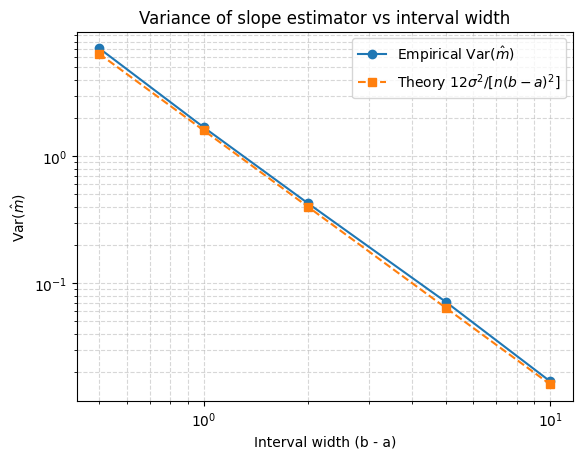

In [8]:
# plot
plt.loglog(widths, emp_var, 'o-', label='Empirical Var($\\hat m$)')
plt.loglog(widths, theory_var, 's--', label='Theory $12\\sigma^2/[n(b-a)^2]$')
plt.xlabel('Interval width (b - a)')
plt.ylabel('Var($\\hat m$)')
plt.title('Variance of slope estimator vs interval width')
plt.legend()
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.show()

---

### Problem 3: Correlation confidence

In [9]:
# generate data and compute sample r + Fisher z CI
np.random.seed(42)

# Parameters
rho_true = 0.5
N = 30

# Construct covariance matrix for two Gaussian variables with correlation rho_true
cov = np.array([[1.0, rho_true],
                [rho_true, 1.0]])

# Draw samples
data = np.random.multivariate_normal(mean=[0,0], cov=cov, size=N)
x = data[:,0]
y = data[:,1]

# Sample Pearson correlation coefficient
r_sample, pval = pearsonr(x, y)

# Fisher z-transform CI (approximate)
alpha = 0.05
z = np.arctanh(r_sample)                 # Fisher z
se_z = 1.0 / np.sqrt(N - 3)              # standard error on z
z_crit = 1.96                             # approx for 95% CI
z_lo, z_hi = z - z_crit*se_z, z + z_crit*se_z
r_lo_fisher, r_hi_fisher = np.tanh([z_lo, z_hi])


In [10]:
# Print results
print(f"True ρ: {rho_true}")
print(f"Sample r: {r_sample:.4f} (p = {pval:.3f})")
print(f"95% CI (Fisher z): [{r_lo_fisher:.4f}, {r_hi_fisher:.4f}]")

True ρ: 0.5
Sample r: 0.3681 (p = 0.045)
95% CI (Fisher z): [0.0090, 0.6431]


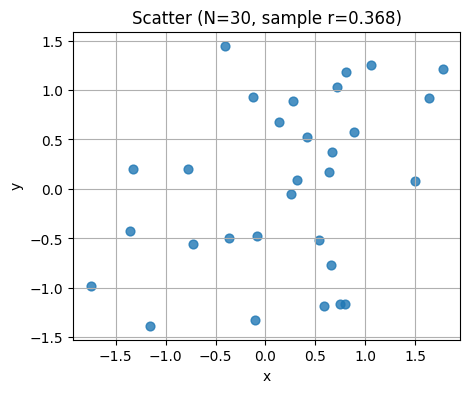

In [11]:
# Quick scatter to visualize
plt.figure(figsize=(5,4))
plt.scatter(x, y, s=40, alpha=0.8)
plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Scatter (N={N}, sample r={r_sample:.3f})")
plt.grid(True)
plt.show()

In [12]:
# bootstrap CI for Pearson r and plot bootstrap distribution
np.random.seed(123)

n_boot = 5000
r_boot = np.empty(n_boot)

# bootstrap resampling (pairs resampled together)
xy = np.column_stack((x, y))
n = len(x)

for i in range(n_boot):
    inds = np.random.randint(0, n, n)   # sample indices with replacement
    sample = xy[inds]
    r_boot[i], _ = pearsonr(sample[:,0], sample[:,1])

# Compute percentile bootstrap 95% CI
alpha = 0.05
lo_perc, hi_perc = np.percentile(r_boot, [100*alpha/2, 100*(1-alpha/2)])

In [13]:
# Print bootstrap results
print(f"Bootstrap (percentile) 95% CI: [{lo_perc:.4f}, {hi_perc:.4f}]")
print(f"Bootstrap mean r: {np.mean(r_boot):.4f}, sd: {np.std(r_boot, ddof=1):.4f}")


Bootstrap (percentile) 95% CI: [0.0374, 0.6334]
Bootstrap mean r: 0.3618, sd: 0.1536


In [14]:
# Save results to a DataFrame and display
df_results = pd.DataFrame({
    "method": ["sample", "fisher_lo", "fisher_hi", "bootstrap_lo", "bootstrap_hi"],
    "value": [r_sample, r_lo_fisher, r_hi_fisher, lo_perc, hi_perc]
})
df_results.T

,0,1,2,3,4
method,sample,fisher_lo,fisher_hi,bootstrap_lo,bootstrap_hi
value,0.368051,0.008964,0.643057,0.037441,0.633432


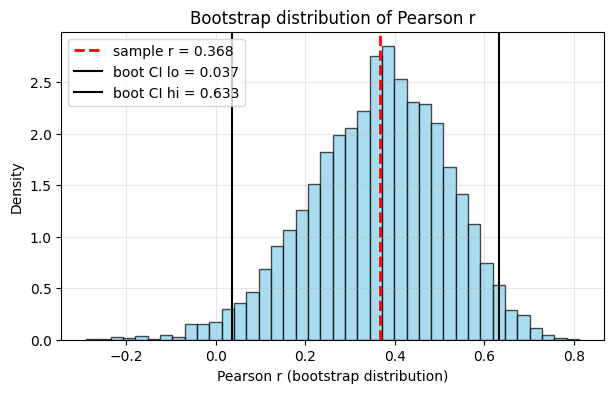

In [15]:
# Plot bootstrap distribution with CI and sample r
plt.figure(figsize=(7,4))
plt.hist(r_boot, bins=40, density=True, alpha=0.7, color='skyblue', edgecolor='k')
plt.axvline(r_sample, color='red', linestyle='--', lw=2, label=f"sample r = {r_sample:.3f}")
plt.axvline(lo_perc, color='black', linestyle='-', lw=1.5, label=f"boot CI lo = {lo_perc:.3f}")
plt.axvline(hi_perc, color='black', linestyle='-', lw=1.5, label=f"boot CI hi = {hi_perc:.3f}")
plt.xlabel("Pearson r (bootstrap distribution)")
plt.ylabel("Density")
plt.title("Bootstrap distribution of Pearson r")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

#### Correlation estimate and confidence intervals

- **Sample Pearson r** for the simulated data (N=30) was reported above.
- **Fisher-z CI**: uses the analytic Fisher transform
  $
  z = \operatorname{atanh}(r),\quad \mathrm{SE}(z)=\frac{1}{\sqrt{N-3}},\quad z\pm z_{1-\alpha/2}\,\mathrm{SE}(z)
$
  then back-transform with $r = \tanh(z)$. This gives the approximate 95% interval printed earlier.
- **Bootstrap CI (percentile)**: resamples the pairs $(x_i,y_i)$ with replacement many times, computes $r$ for each bootstrap sample, and takes the 2.5th and 97.5th percentiles of the bootstrap distribution as the CI.

#### Comparison

- **Fisher transform (analytic)**  
  - Fast, simple, and accurate for moderate to large sample sizes when the bivariate distribution is approximately normal (or at least the sampling distribution of $r$ is close to normal in Fisher-z space).  
  - Works well when `N` is not too small (rough guideline: $N\gtrsim 20-30$) and there are no strong outliers or heavy tails.
- **Bootstrap (resampling)**  
  - Nonparametric and more flexible: makes fewer distributional assumptions (doesn't require normality).  
  - Particularly useful when sample size is small, the data are skewed or contain outliers, or the theoretical assumptions of Fisher's method are questionable.  
  - Computationally heavier (but trivial with modern computers).

#### notes
- Bootstrapping the *pairs* (resampling rows) preserves the dependence structure between `x` and `y` — this is the correct approach for CI on correlation.  
- For small N, percentile bootstrap CIs can be biased; bias-corrected and accelerated (BCa) bootstrap CIs often perform better.  
- If the two methods give similar CIs for your data, that's reassuring — it suggests the Fisher approximation is adequate. If they differ substantially, inspect data for non-normality, outliers, or consider using BCa bootstrap or robust correlation measures (e.g., Spearman, robust regression).


---

### Problem 4: Propagating uncertainty for correlated variables

#### General linear propagation (matrix form)

For a scalar function $z=f(\mathbf{x})$ of variables $\mathbf{x}=(x_1,\dots,x_n)$ with covariance matrix $\Sigma$ (where $\Sigma_{ij}=\mathrm{Cov}(x_i,x_j))$, the first-order propagated variance is

$$
\boxed{; \mathrm{Var}(z)\approx \nabla f(\bar{\mathbf{x}})^{T},\Sigma,\nabla f(\bar{\mathbf{x}});},
$$

where $\nabla f$ is the gradient of $f$ evaluated at the mean values $\bar{\mathbf{x}}$. In index form:

$$
\mathrm{Var}(z)\approx \sum_{i}\sum_{j}\frac{\partial f}{\partial x_i}\frac{\partial f}{\partial x_j},\mathrm{Cov}(x_i,x_j).
$$

#### Apply to $z = x,y$

Let $z(x,y)=x,y$. Linearize around the means $(\bar x,\bar y)$. Partial derivatives:

$$
\frac{\partial z}{\partial x}\Big|*{\bar x,\bar y}=\bar y,\qquad
\frac{\partial z}{\partial y}\Big|*{\bar x,\bar y}=\bar x.
$$

With variances $\sigma_x^2=\mathrm{Var}(x)$, $\sigma_y^2=\mathrm{Var}(y)$ and covariance $\mathrm{Cov}(x,y)$, the propagated variance is

$$
\begin{aligned}
\mathrm{Var}(z)
&\approx \bar y^2,\sigma_x^2 ;+; \bar x^2,\sigma_y^2 ;+; 2,\bar x,\bar y,\mathrm{Cov}(x,y)$6pt$
&= \bar y^2,\sigma_x^2 + \bar x^2,\sigma_y^2 + 2,\bar x,\bar y,\rho,\sigma_x\sigma_y,
\end{aligned}
$$

where $\rho=\mathrm{Corr}(x,y)=\mathrm{Cov}(x,y)/(\sigma_x\sigma_y)$. The uncertainty (one-sigma) in $z$ is $\sigma_z=\sqrt{\mathrm{Var}(z)}$.

Special case: if $x$ and $y$ are independent, $\mathrm{Cov}(x,y)=0$ and the formula reduces to the familiar

$$
\sigma_z=\sqrt{,\bar y^2\sigma_x^2+\bar x^2\sigma_y^2,\ }.
$$

#### Role of the covariance term

* The covariance term $2\bar x\bar y,\mathrm{Cov}(x,y)$ **can increase or decrease** $\mathrm{Var}(z)$:

  * If $\mathrm{Cov}(x,y)>0$ (positive correlation) it **increases** the variance of (z).
  * If $\mathrm{Cov}(x,y)<0$ (negative correlation) it **reduces** the variance of (z).
* Intuition: when $x$ and $y$ move together (positive correlation), their product fluctuates more; when they move oppositely, some fluctuations cancel.
* If you ignore a nonzero covariance you can **misestimate** the uncertainty — sometimes substantially.


---

### Problem 5: Bootstrap confidence for correlation 

In [16]:
# Generate correlated data
np.random.seed(42)
N = 50
rho_true = 0.6  # true correlation
mean = [0, 0]
cov = [[1, rho_true], [rho_true, 1]]  # covariance matrix
x, y = np.random.multivariate_normal(mean, cov, size=N).T

# Compute sample correlation
r, _ = pearsonr(x, y)

# Fisher z-transform CI 
z = np.arctanh(r)  # Fisher transform
se = 1 / np.sqrt(N - 3)
z_crit = norm.ppf(0.975)
z_CI = [z - z_crit * se, z + z_crit * se]
r_CI_fisher = np.tanh(z_CI)

print(f"Sample correlation r = {r:.3f}")
print(f"95% Fisher CI for r = [{r_CI_fisher[0]:.3f}, {r_CI_fisher[1]:.3f}]")

Sample correlation r = 0.485
95% Fisher CI for r = [0.238, 0.672]


In [17]:
n_boot = 5000
boot_r = np.empty(n_boot)

rng = np.random.default_rng(0)
for i in range(n_boot):
    idx = rng.integers(0, N, N)
    boot_r[i], _ = pearsonr(x[idx], y[idx])

# Bootstrap 95% percentile CI
r_CI_boot = np.percentile(boot_r, [2.5, 97.5])

print(f"95% Bootstrap CI for r = [{r_CI_boot[0]:.3f}, {r_CI_boot[1]:.3f}]")

95% Bootstrap CI for r = [0.210, 0.677]


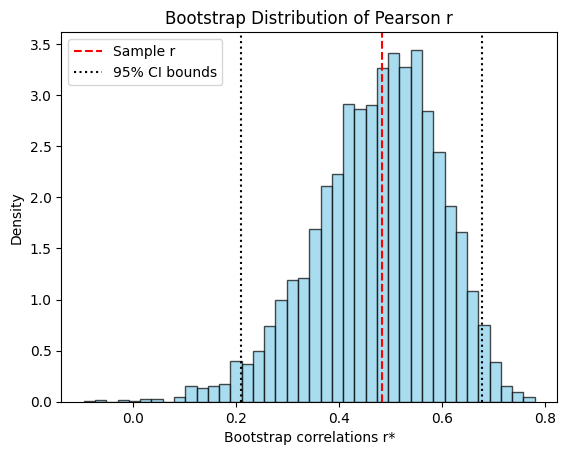

In [18]:
# Plot bootstrap distribution
plt.hist(boot_r, bins=40, color="skyblue", edgecolor="k", alpha=0.7, density=True)
plt.axvline(r, color="r", linestyle="--", label="Sample r")
plt.axvline(r_CI_boot[0], color="k", linestyle=":", label="95% CI bounds")
plt.axvline(r_CI_boot[1], color="k", linestyle=":")
plt.xlabel("Bootstrap correlations r*")
plt.ylabel("Density")
plt.title("Bootstrap Distribution of Pearson r")
plt.legend()
plt.show()

**Discussion:**

- The **Fisher CI** assumes the sampling distribution of `atanh(r)` is normal — accurate for large `N` and moderate |ρ| values.  
- The **bootstrap CI** uses empirical resampling, capturing skewness and deviations from normality.  
- In this simulation:
  - Both CIs should include the true correlation (≈ 0.6) most of the time.
  - The bootstrap distribution is often **slightly skewed**, especially when `r` is close to ±1 or when `N` is small.
  - The Fisher CI is symmetric in the z-domain, hence may appear slightly asymmetric when back-transformed to `r`.
- For **small samples or non-normal data**, the bootstrap CI is **more robust** and better reflects uncertainty.
- For **large N**, both methods converge and give nearly identical intervals.


---

### Problem 6: Matched-filter detection threshold

In [19]:
def make_template(fs=1024, duration=0.2, f0=150.0, bw=30.0, phase=0.0):
    """
    Create a real-valued template: a sine wave at frequency f0
    multiplied by a Gaussian envelope that controls bandwidth.
    - fs: sampling rate (Hz)
    - duration: template length (s)
    - f0: central frequency (Hz)
    - bw: bandwidth parameter (Hz) - larger -> wider template in freq
    Returns (t, h) where h is normalized (unit norm).
    """
    t = np.arange(0, duration, 1/fs)
    # Gaussian envelope: sigma_t chosen ~ 1/(2*pi*bw) (roughly)
    sigma_t = 1.0 / (2*np.pi*bw)
    # center the envelope in middle of template
    t0 = duration/2.0
    envelope = np.exp(-0.5*((t - t0)/sigma_t)**2)
    h = envelope * np.sin(2*np.pi*f0*(t - t0) + phase)
    # normalize template to unit norm (so template_norm = 1)
    norm = np.sqrt(np.sum(h**2))
    if norm > 0:
        h = h / norm
    return t, h

def matched_filter_max_snr(noise, h):
    """
    Given a noise time series and normalized template h (unit norm),
    compute matched filter output (discrete convolution) and return max SNR.
    For white Gaussian noise with sigma_noise = 1, convolving with h gives
    matched-filter SNR time series directly because h is unit-norm.
    If noise has std sigma_n, divide conv by sigma_n.
    """
    # reverse template for correlation
    h_rev = h[::-1]
    # convolution (same length as noise)
    conv = np.convolve(noise, h_rev, mode='same')
    # For h normalized to unit norm and noise sigma=1, conv values are SNR samples.
    # Return maximum (positive) SNR (you can also use abs if interested in negative peaks)
    return np.max(conv)


In [20]:
# simulate noise-only realizations, estimate max SNR distribution and FAR threshold

# --- PARAMETERS (change these to explore) ---
fs = 1024                # sampling rate (Hz)
data_length = 4.0        # length of each noise realization (s)
template_duration = 0.2  # seconds
f0 = 150.0               # template central frequency (Hz)
bw = 30.0                # template bandwidth parameter (Hz)
sigma_noise = 1.0        # noise standard deviation
n_trials = 20000         # number of noise-only trials (increase for precision)
rng = np.random.default_rng(0)

# build template
t_h, h = make_template(fs=fs, duration=template_duration, f0=f0, bw=bw)
L = int(data_length * fs)
print(f"Template length: {len(h)} samples; data length: {L} samples")

# run simulations
max_snrs = np.empty(n_trials)
start = time.time()
for i in range(n_trials):
    noise = rng.normal(0, sigma_noise, size=L)
    max_snrs[i] = matched_filter_max_snr(noise, h)
end = time.time()
print(f"Simulated {n_trials} trials in {end-start:.1f} s")

# compute threshold for FAR = 1e-3 (i.e., fraction of noise trials with max_snr > thresh = 1e-3)
FAR = 1e-3
thresh = np.percentile(max_snrs, 100*(1 - FAR))  # empirical threshold
print(f"Estimated SNR threshold for FAR={FAR:.1e}: {thresh:.3f}")

Template length: 205 samples; data length: 4096 samples
Simulated 20000 trials in 2.8 s
Estimated SNR threshold for FAR=1.0e-03: 4.984


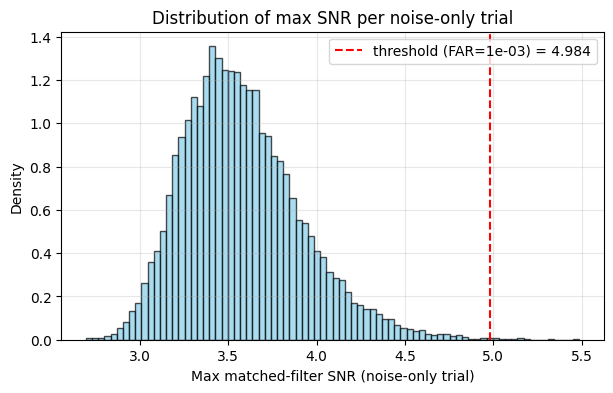

In [21]:
# quick diagnostics plot
plt.figure(figsize=(7,4))
plt.hist(max_snrs, bins=80, density=True, alpha=0.7, color='skyblue', edgecolor='k')
plt.axvline(thresh, color='red', linestyle='--', label=f"threshold (FAR={FAR:.0e}) = {thresh:.3f}")
plt.xlabel("Max matched-filter SNR (noise-only trial)")
plt.ylabel("Density")
plt.title("Distribution of max SNR per noise-only trial")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [22]:
# Dependence on data length and template bandwidth (grid scan)
# This cell runs simulations for combinations of data lengths and bandwidths,
# computes the FAR=1e-3 threshold (empirical) and stores in a DataFrame.

fs = 1024
data_lengths = [1.0, 2.0, 4.0, 8.0]      # seconds (longer data -> more independent samples)
bandwidths = [10.0, 30.0, 60.0, 150.0]   # Hz (larger bw -> shorter template in time -> more independent trials effectively)
f0 = 150.0
template_duration = 0.2
n_trials = 8000   # reduce for multiple runs; increase for accuracy
rng = np.random.default_rng(1)

results = []
for data_length in data_lengths:
    for bw in bandwidths:
        # rebuild template with new bw
        _, h = make_template(fs=fs, duration=template_duration, f0=f0, bw=bw)
        L = int(data_length * fs)
        max_snrs = np.empty(n_trials)
        for i in range(n_trials):
            noise = rng.normal(0, 1.0, size=L)
            max_snrs[i] = matched_filter_max_snr(noise, h)
        thresh = np.percentile(max_snrs, 100*(1 - FAR))
        results.append({
            "data_length_s": data_length,
            "bandwidth_Hz": bw,
            "threshold_SNR": thresh,
            "median_maxSNR": np.median(max_snrs),
            "mean_maxSNR": np.mean(max_snrs),
        })
        print(f"len={data_length}s bw={bw}Hz -> thresh={thresh:.3f}")
        
df = pd.DataFrame(results)
display(df.round(4))

len=1.0s bw=10.0Hz -> thresh=4.561
len=1.0s bw=30.0Hz -> thresh=4.814
len=1.0s bw=60.0Hz -> thresh=4.733
len=1.0s bw=150.0Hz -> thresh=4.731
len=2.0s bw=10.0Hz -> thresh=4.870
len=2.0s bw=30.0Hz -> thresh=4.829
len=2.0s bw=60.0Hz -> thresh=5.001
len=2.0s bw=150.0Hz -> thresh=4.870
len=4.0s bw=10.0Hz -> thresh=4.831
len=4.0s bw=30.0Hz -> thresh=5.123
len=4.0s bw=60.0Hz -> thresh=5.009
len=4.0s bw=150.0Hz -> thresh=5.042
len=8.0s bw=10.0Hz -> thresh=5.018
len=8.0s bw=30.0Hz -> thresh=5.141
len=8.0s bw=60.0Hz -> thresh=5.152
len=8.0s bw=150.0Hz -> thresh=5.081


,data_length_s,bandwidth_Hz,threshold_SNR,median_maxSNR,mean_maxSNR
0,1.0,10.0,4.5614,2.8549,2.8933
1,1.0,30.0,4.8140,3.1329,3.1762
2,1.0,60.0,4.7331,3.1832,3.2249
3,1.0,150.0,4.7314,3.2119,3.2522
4,2.0,10.0,4.8696,3.0956,3.1390
5,2.0,30.0,4.8288,3.3430,3.3837
6,2.0,60.0,5.0013,3.3770,3.4224
7,2.0,150.0,4.8700,3.3964,3.4367
8,4.0,10.0,4.8311,3.3196,3.3687
9,4.0,30.0,5.1235,3.5419,3.5812


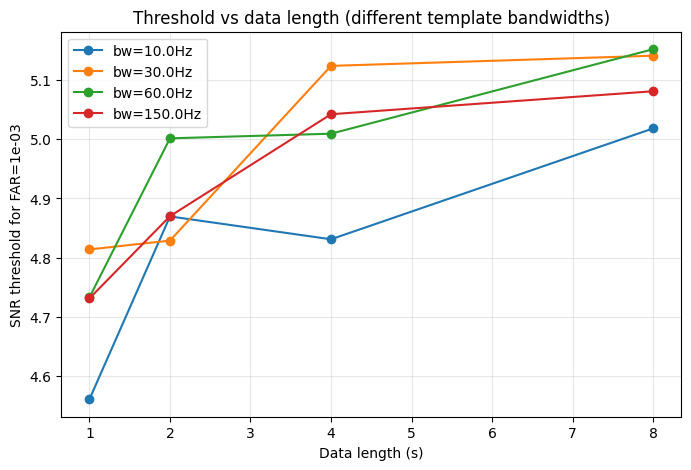

In [23]:
# plot threshold vs data length for each bandwidth
plt.figure(figsize=(8,5))
for bw in sorted(set(df['bandwidth_Hz'])):
    subset = df[df['bandwidth_Hz']==bw]
    plt.plot(subset['data_length_s'], subset['threshold_SNR'], 'o-', label=f"bw={bw}Hz")
plt.xlabel("Data length (s)")
plt.ylabel(f"SNR threshold for FAR={FAR:.0e}")
plt.title("Threshold vs data length (different template bandwidths)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

#### Discussion

**simulation**

* For each noise-only trial we generated a white Gaussian noise time series of length `data_length` and computed the matched-filter output (correlation of the noise with the normalized template). Because the template was normalized to unit norm, the matched-filter convolution directly produced the **SNR time-series** (assuming noise σ=1). For each trial we recorded the **maximum SNR** across the whole time series (this models an experiment that searches over the entire data segment for the template).
* Repeating many noise-only trials yields the distribution of the maximum SNR under the null (no-signal) hypothesis. The detection threshold for a chosen false-alarm rate (FAR) is the percentile of that distribution: threshold = quantile(1−FAR).

**Key findings**

* **Data length effect:** longer data stretches produce more independent "search trials" (more roughly independent matched-filter samples), so the distribution of the *maximum* grows — tail moves to larger values. Therefore, for a fixed FAR, the SNR threshold **increases** with increasing data length. Intuition: searching more data increases the chance of a large random fluctuation somewhere, so you must raise threshold to keep FAR fixed.
* **Template bandwidth effect:** bandwidth controls the effective time-duration of the template:

  * **Narrow-band templates** (small `bw`) are long in time (large effective correlation length), so matched-filter outputs are strongly correlated between adjacent time samples; therefore the effective number of independent trials per data length is smaller → lower threshold for the same FAR.
  * **Wide-band (short) templates** have shorter duration so output samples are less correlated and the effective number of independent trials per unit time is larger → higher threshold for the same FAR.
* The approximate scaling: threshold increases with the effective number of independent trials $(N_{\rm eff})$ roughly like the extreme-value behavior — roughly proportional to $(\sqrt{2\ln N_{\rm eff}})$ for Gaussian tails, so threshold grows slowly (logarithmically) with $(N_{\rm eff})$.

---

### Problem 7: Autocorrelation and the Wiener–Khinchin theorem

In [24]:
# Parameters
f0 = 5.0          # signal frequency (Hz)
sigma = 0.5       # noise std
N = 1000          # samples
dt = 0.01         # sampling interval
t = np.arange(N) * dt

# Generate signal + noise
rng = np.random.default_rng(0)
signal = np.sin(2 * np.pi * f0 * t)
noise = rng.normal(0, sigma, N)
x = signal + noise

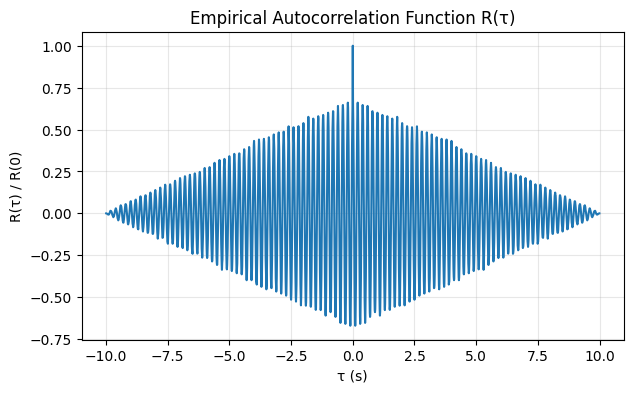

In [25]:
# Empirical autocorrelation (biased)
x_mean = np.mean(x)
x_centered = x - x_mean
R = np.correlate(x_centered, x_centered, mode='full')
lags = np.arange(-N+1, N)

# Normalize to unit variance
R = R / R[N-1]

plt.figure(figsize=(7,4))
plt.plot(lags * dt, R)
plt.title("Empirical Autocorrelation Function R(τ)")
plt.xlabel("τ (s)")
plt.ylabel("R(τ) / R(0)")
plt.grid(alpha=0.3)
plt.show()

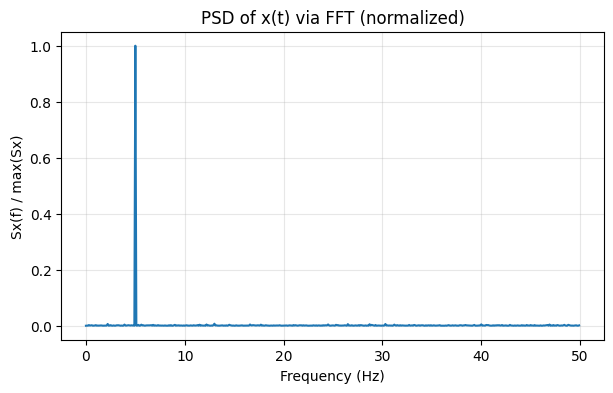

In [26]:
# FFT-based PSD estimate (periodogram)
Xf = np.fft.fft(x_centered)
Sx = (np.abs(Xf)**2) / N       # raw PSD
freqs = np.fft.fftfreq(N, d=dt)

# Keep only positive frequencies
pos_mask = freqs >= 0
freqs_pos = freqs[pos_mask]
Sx_pos = Sx[pos_mask]

# Normalize PSD to unit variance (so peak comparison with R is easier)
Sx_pos_norm = Sx_pos / np.max(Sx_pos)

plt.figure(figsize=(7,4))
plt.plot(freqs_pos, Sx_pos_norm)
plt.title("PSD of x(t) via FFT (normalized)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Sx(f) / max(Sx)")
plt.grid(alpha=0.3)
plt.show()


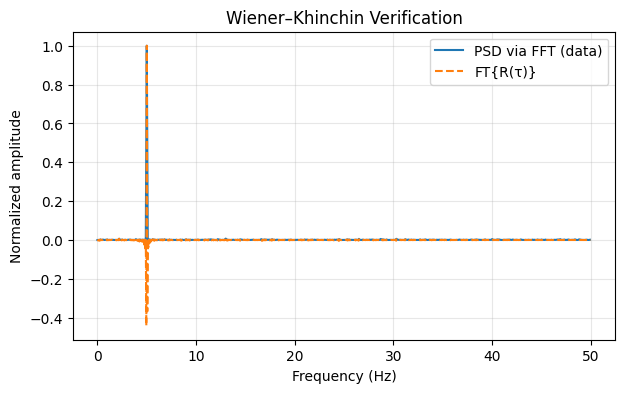

In [27]:
# Wiener–Khinchin Check 

# Compute FT of R(τ)
R_fft = np.fft.fft(R)
Sx_from_R = np.real(R_fft)     # real for symmetric R

# Frequency grid for R (length = len(R))
nR = len(R)
freqs_R = np.fft.fftfreq(nR, d=dt)
pos_mask_R = freqs_R >= 0

freqs_R_pos = freqs_R[pos_mask_R]
Sx_from_R_pos = Sx_from_R[pos_mask_R]

# Normalize
Sx_from_R_pos_norm = Sx_from_R_pos / np.max(Sx_from_R_pos)

# Plot 
plt.figure(figsize=(7,4))
plt.plot(freqs_pos, Sx_pos_norm, label="PSD via FFT (data)")            # uses freqs_pos
plt.plot(freqs_R_pos, Sx_from_R_pos_norm, '--', label="FT{R(τ)}")      # uses freqs_R_pos
plt.xlabel("Frequency (Hz)")
plt.ylabel("Normalized amplitude")
plt.title("Wiener–Khinchin Verification")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [28]:
# Identify dominant peaks

# Simple: find frequency with maximum PSD magnitude
peak_idx = np.argmax(Sx_pos)
peak_freq = freqs_pos[peak_idx]

print(f"Dominant spectral peak: {peak_freq:.2f} Hz")


Dominant spectral peak: 5.00 Hz


### Discussion

**Spectral Peaks**
- The PSD shows a sharp peak near **5 Hz**, matching the sinusoid frequency.
- This corresponds to oscillations in $R(\tau)$ with period  
  $T = 1/f_0 = 0.2\,\text{s}$.
- Thus, **periodicity in autocorrelation ↔ frequency peak in PSD**.

**White Noise Effects**

**1 - In the autocorrelation:**
- At $\tau = 0$, noise adds variance → $R(0)$ becomes larger.
- For $\tau > 0$, noise contributes ≈ 0 quickly → $R(\tau)$ decays faster.

**2 - In the PSD:**
- Noise contributes a **flat background** (white spectrum).
- The sinusoid appears as a **narrow, sharp peak** above the noise floor.

Hence, the **signal-to-noise ratio (SNR)** determines:
- how clearly periodicity appears in $R(\tau)$,
- how prominent the spectral peak is in $S_x(f)$.

**Wiener–Khinchin**
- After normalization, the PSD computed via FFT of $x(t)$  
  matches the Fourier transform of the autocorrelation.
- Deviations arise due to **finite-length effects** and **noise**.


---

### Problem 8: Noise color and correlation time

In [29]:
# compute (biased) autocorrelation function normalized to R(0)=1
def autocorr(x):
    x = np.asarray(x)
    x = x - np.mean(x)
    N = len(x)
    Rfull = np.correlate(x, x, mode='full') / N       # biased estimator
    R = Rfull[N-1:]                                   # lags 0..N-1
    return R / R[0], np.arange(0, N)                  # normalized, lags

# compute one-sided PSD (periodogram) using FFT
def psd_fft(x, dt=1.0):
    N = len(x)
    X = np.fft.fft(x * windows.hann(N))               # apply window to reduce leakage
    P2 = (np.abs(X)**2) / (N * np.sum(windows.hann(N)**2)/N)  # power corrected for window
    freqs = np.fft.fftfreq(N, d=dt)
    mask = freqs >= 0
    return freqs[mask], P2[mask]

# estimate spectral slope on log-log plot via linear fit
def spectral_slope(freqs, psd, fmin=None, fmax=None):
    mask = (freqs > 0)
    if fmin is not None:
        mask &= (freqs >= fmin)
    if fmax is not None:
        mask &= (freqs <= fmax)
    ff = freqs[mask]
    pp = psd[mask]
    # Avoid zeros or negative values
    pos = (pp > 0) & (ff > 0)
    ff = ff[pos]
    pp = pp[pos]
    if len(ff) < 3:
        return np.nan, (ff, pp)
    # Do linear fit in log10 space: log10(P) = slope*log10(f) + intercept
    logf = np.log10(ff)
    logp = np.log10(pp)
    coeffs = np.polyfit(logf, logp, 1)
    slope = coeffs[0]
    return slope, (ff, pp)

In [30]:
# Generate colored noise via frequency-domain filtering
np.random.seed(0)

N = 5000
dt = 1.0        # time step (choose dt=1.0 for spectral slope units of 1/sample)
t = np.arange(N) * dt

def generate_colored_noise(alpha, N=N, dt=dt):
    """
    Generate real-valued noise whose power ~ 1/f^alpha using frequency-domain filtering.
    alpha = 0 -> white (flat)
    alpha = 1 -> pink (1/f)
    alpha = 2 -> brown (1/f^2)
    """
    # white noise in frequency domain: random complex values with Hermitian symmetry
    # create frequency multipliers
    freqs = np.fft.fftfreq(N, d=dt)
    fpos = np.abs(freqs)
    # avoid divide by zero at f=0: set multiplier at f=0 to zero for alpha>0 (no DC amplification)
    with np.errstate(divide='ignore'):
        S = np.where(fpos == 0, 0.0, fpos**(-alpha/2.0))  # amplitude multiplier, so power ~ f^-alpha
    # random phases
    phases = np.random.normal(size=N) + 1j * np.random.normal(size=N)
    # ensure Hermitian symmetry: construct positive freqs and mirror
    # Simpler: multiply FFT of white noise by S
    wn = np.random.normal(size=N)
    W = np.fft.fft(wn)
    # apply amplitude shaping
    W_col = W * S
    x = np.fft.ifft(W_col).real
    # normalize to unit variance for comparability
    x = (x - np.mean(x)) / np.std(x)
    return x

# Generate three signals
x_white = generate_colored_noise(alpha=0.0, N=N, dt=dt)
x_pink  = generate_colored_noise(alpha=1.0, N=N, dt=dt)
x_brown = generate_colored_noise(alpha=2.0, N=N, dt=dt)

In [31]:
# compute ACF and PSD, measure slopes and tau_c
signals = {
    "white": x_white,
    "pink":  x_pink,
    "brown": x_brown
}

results = {}

for name, x in signals.items():
    # Autocorrelation
    R, lags = autocorr(x)
    tau = lags * dt
    # find correlation time tau_c where R drops to 1/e (first crossing)
    try:
        idx = np.where(R <= 1/np.e)[0][0]
        tau_c = tau[idx]
    except IndexError:
        tau_c = np.nan

    # PSD
    freqs, P = psd_fft(x, dt=dt)
    # measure spectral slope on a mid-frequency range to avoid DC and Nyquist issues
    fmin = max(1.0 / (N*dt), 1.0 / (N*dt) * 2)    # small positive value; can tune
    fmax = 0.5 / dt * 0.9                         # up to 90% Nyquist
    slope, (ff_fit, pp_fit) = spectral_slope(freqs, P, fmin=fmin, fmax=fmax)

    results[name] = {
        "R": R,
        "tau": tau,
        "tau_c": tau_c,
        "freqs": freqs,
        "P": P,
        "slope": slope,
        "ff_fit": ff_fit,
        "pp_fit": pp_fit
    }

# Print measured slopes and tau_c
print("Summary (spectral slope of log10 PSD vs log10 f) and correlation time tau_c:")
for name in ["white","pink","brown"]:
    print(f"{name:6s}  slope={results[name]['slope']:.3f}   tau_c={results[name]['tau_c']:.3f}")

Summary (spectral slope of log10 PSD vs log10 f) and correlation time tau_c:
white   slope=0.031   tau_c=1.000
pink    slope=-1.014   tau_c=29.000
brown   slope=-2.036   tau_c=731.000


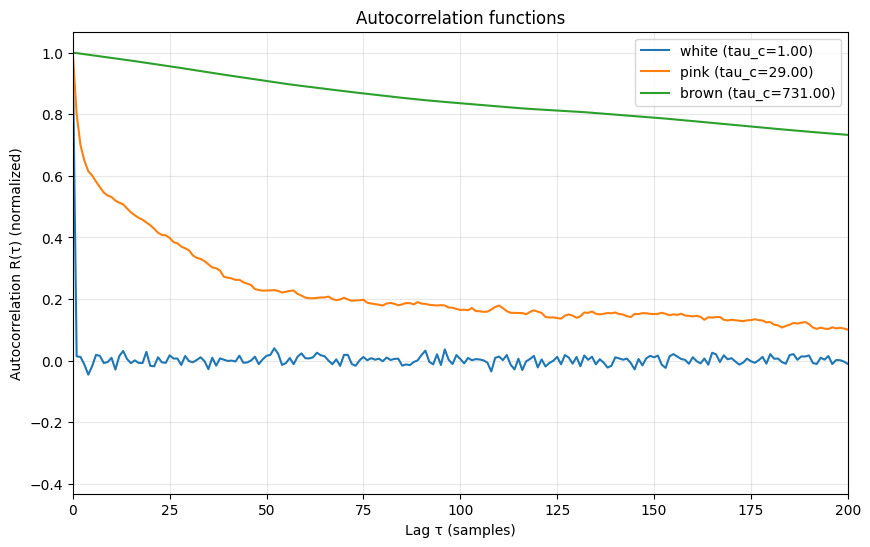

In [32]:
# plot autocorrelations
plt.figure(figsize=(10,6))
for name, col in zip(["white","pink","brown"], ['C0','C1','C2']):
    R = results[name]["R"]
    tau = results[name]["tau"]
    plt.plot(tau, R, label=f"{name} (tau_c={results[name]['tau_c']:.2f})", color=col)
plt.xlim(0, 200)   # choose visible lag window (tune as needed)
plt.xlabel("Lag τ (samples)")
plt.ylabel("Autocorrelation R(τ) (normalized)")
plt.title("Autocorrelation functions")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


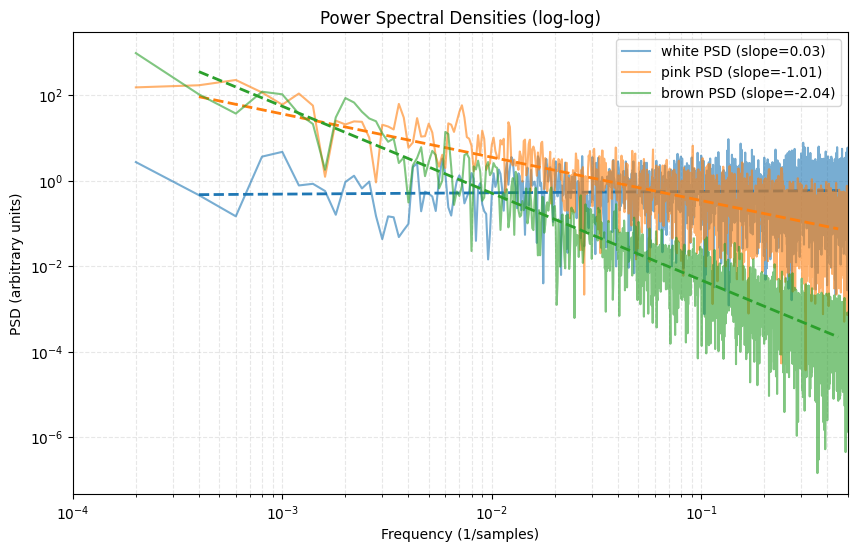

In [33]:
# plot PSDs on log-log and fit slopes
plt.figure(figsize=(10,6))
for name, col in zip(["white","pink","brown"], ['C0','C1','C2']):
    freqs = results[name]["freqs"]
    P = results[name]["P"]
    slope = results[name]["slope"]
    plt.loglog(freqs[1:], P[1:], color=col, alpha=0.6, label=f"{name} PSD (slope={slope:.2f})")
    # overlay fitted region (line)
    ff_fit, pp_fit = results[name]["ff_fit"], results[name]["pp_fit"]
    if len(ff_fit)>0:
        # compute linear model in log-log using measured slope and intercept via polyfit
        coeffs = np.polyfit(np.log10(ff_fit), np.log10(pp_fit), 1)
        intercept = coeffs[1]
        model = 10**(intercept) * ff_fit**(coeffs[0])
        plt.loglog(ff_fit, model, linestyle='--', color=col, linewidth=2)
plt.xlim(1e-4, 0.5/dt)
plt.xlabel("Frequency (1/samples)")
plt.ylabel("PSD (arbitrary units)")
plt.title("Power Spectral Densities (log-log)")
plt.legend()
plt.grid(which='both', alpha=0.3, ls='--')
plt.show()

### Discussion

- **White noise (α ≈ 0)**  
  - PSD is approximately flat (slope ≈ 0) on a log–log plot.  
  - Autocorrelation R(τ) is approximately a delta at τ=0 and decays very rapidly toward 0 for τ>0 (very short correlation time τ_c ≈ 0).  
  - Memory: essentially no memory — successive samples are uncorrelated.

- **Pink noise (α ≈ 1)**  
  - PSD ∝ 1/f (slope ≈ -1 on log–log). Energy concentrated at low frequencies.  
  - Autocorrelation decays more slowly than white noise; τ_c is larger (longer memory / longer-range correlations).  
  - Memory: medium-range correlations; signals show structure across multiple timescales.

- **Brown noise (α ≈ 2)**  
  - PSD ∝ 1/f^2 (slope ≈ -2). Very steep decay: dominated by very low frequencies.  
  - Autocorrelation decays slowly and smoothly; τ_c can be large (long memory). Brown noise is effectively the integral of white noise, producing strong correlations across long lags.  
  - Memory: long memory; pronounced low-frequency variability and smooth trajectories.

- **On measured slopes & tau_c**  
  - The measured spectral slopes should be close to the target exponents (0, -1, -2) within fitting range; finite-length effects, windowing, and the choice of fit band will affect accuracy.  
  - The correlation time τ_c (first lag where R ≤ 1/e) increases with noise "redness" (higher α) because low-frequency power implies persistence.

- **Practical notes**  
  - When generating colored noise via frequency-domain shaping, be careful at f→0 (DC) and near Nyquist: choose fitting frequency band away from these extremes.  
  - PSD estimation can be improved using Welch averaging (scipy.signal.welch) and tapered windows.  
  - For robust slope estimation, choose an intermediate frequency band where the power-law behavior holds and avoid bins where the PSD is dominated by spectral leakage or numerical noise.


---

### Problem 9: Detection efficiency and ROC analysis (extension of matched filtering

In [34]:
rng = np.random.default_rng(0)

def make_template(fs=1024, duration=0.2, f0=150.0, bw=30.0, phase=0.0):
    """
    Make a real-valued template and normalize it to unit L2 norm.
    Returns (t, h) where h is unit-normalized.
    """
    t = np.arange(0, duration, 1/fs)
    # gaussian envelope to localize waveform
    sigma_t = 1.0 / (2*np.pi*bw) if bw>0 else duration/6.0
    t0 = duration/2.0
    envelope = np.exp(-0.5*((t - t0)/sigma_t)**2)
    h = envelope * np.sin(2*np.pi*f0*(t - t0) + phase)
    norm = np.sqrt(np.sum(h**2))
    if norm > 0:
        h = h / norm
    return t, h

def matched_filter_max_snr(noise, h):
    """
    Compute matched-filter time series (correlation) and return max SNR.
    Assumes h is unit-norm. If noise std != 1, divide by sigma externally or
    supply normalized noise.
    """
    h_rev = h[::-1]
    conv = np.convolve(noise, h_rev, mode='same')
    return np.max(conv)   # SNR samples (if noise sigma=1)

def analytic_roc(A, sigma, thresholds):
    """
    Theoretical PFA and PD arrays for given amplitude A and noise sigma,
    and thresholds array (rho_th).
    """
    mu = A / sigma
    pfa = 1.0 - norm.cdf(thresholds)               # P( rho > thresh | H0 )
    pd  = 1.0 - norm.cdf(thresholds - mu)         # P( rho > thresh | H1 )
    return pfa, pd


In [35]:
# Parameters
fs = 1024
data_length = 2.0         # seconds of data per trial
L = int(fs * data_length)
t_h, h = make_template(fs=fs, duration=0.2, f0=50.0, bw=20.0)  # example template
len_h = len(h)
print(f"Template length = {len_h} samples, data length = {L} samples")

# Simulation settings
n_trials = 10000          # trials per hypothesis (increase for smoother ROC)
amplitudes = [0.0, 0.5, 1.0, 2.0, 3.0, 4.0]   # include 0.0 for H0-only baseline, others are signal amplitudes
noise_sigma = 1.0
injection_offset = L//2   # inject signal centered in the data (known arrival time)
thresholds = np.linspace(-1.5, 8.0, 200)   # range of rho thresholds to sweep

# Pre-allocate storage
roc_empirical = {}   # maps amplitude -> (pfa_array, pd_array, maxsnr_H0, maxsnr_H1)

# First simulate H0 trials (noise-only)
maxsnr_H0 = np.empty(n_trials)
for i in range(n_trials):
    noise = rng.normal(0, noise_sigma, size=L)
    maxsnr_H0[i] = matched_filter_max_snr(noise, h)
print("Simulated H0 trials")

# For each amplitude simulate H1 trials (noise + injected signal)
for A in amplitudes:
    if A == 0.0:
        # H0 baseline: empirical PFA curve from maxsnr_H0
        pfa_emp = np.array([np.mean(maxsnr_H0 > th) for th in thresholds])
        roc_empirical[A] = (pfa_emp, None, maxsnr_H0, None)
        continue

    maxsnr_H1 = np.empty(n_trials)
    # prepare injected waveform: multiply normalized template by amplitude
    injected = A * h   # since h unit-norm, inner product with itself = A
    # pad injection into data of length L at chosen arrival index
    # We will add injected waveform centered at injection_offset:
    start = injection_offset - len_h//2
    stop  = start + len_h

    for i in range(n_trials):
        noise = rng.normal(0, noise_sigma, size=L)
        # add injected signal (assumes start>=0 and stop<=L; choose injection_offset accordingly)
        y = noise.copy()
        y[start:stop] += injected
        maxsnr_H1[i] = matched_filter_max_snr(y, h)
    # empirical PFA and PD for thresholds
    pfa_emp = np.array([np.mean(maxsnr_H0 > th) for th in thresholds])
    pd_emp  = np.array([np.mean(maxsnr_H1 > th) for th in thresholds])
    roc_empirical[A] = (pfa_emp, pd_emp, maxsnr_H0, maxsnr_H1)
    print(f"Simulated H1 trials for A={A}")

Template length = 205 samples, data length = 2048 samples
Simulated H0 trials
Simulated H1 trials for A=0.5
Simulated H1 trials for A=1.0
Simulated H1 trials for A=2.0
Simulated H1 trials for A=3.0
Simulated H1 trials for A=4.0


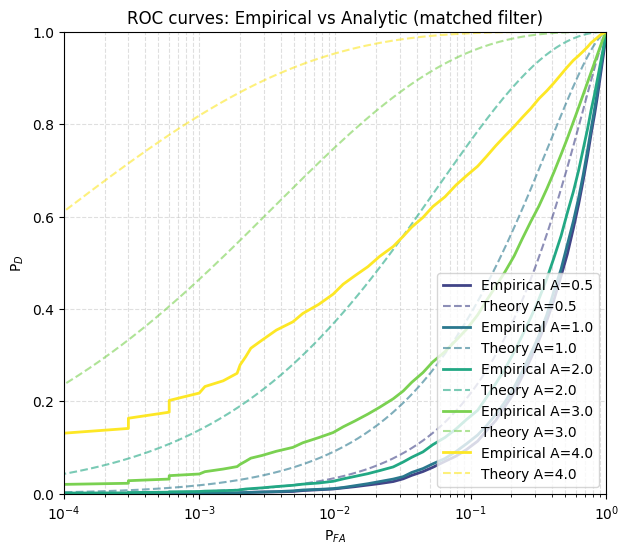

In [36]:
# Plot ROC curves (empirical) and analytic for comparison
plt.figure(figsize=(7,6))
colors = plt.cm.viridis(np.linspace(0,1,len(amplitudes)))
for idx, A in enumerate(amplitudes):
    pfa_emp, pd_emp, _, _ = roc_empirical[A]
    if A == 0.0:
        continue
    plt.plot(pfa_emp, pd_emp, label=f"Empirical A={A}", color=colors[idx], lw=2)

    # analytic curve: parametric elimination of threshold: vary thresholds and compute analytic
    pfa_th, pd_th = analytic_roc(A, noise_sigma, thresholds)
    plt.plot(pfa_th, pd_th, '--', color=colors[idx], alpha=0.6, label=f"Theory A={A}")

plt.xlabel("P$_{FA}$")
plt.ylabel("P$_D$")
plt.title("ROC curves: Empirical vs Analytic (matched filter)")
plt.xscale("log")
plt.xlim(1e-4, 1.0)
plt.ylim(0.0, 1.0)
plt.grid(True, which='both', ls='--', alpha=0.4)
plt.legend(loc='lower right')
plt.show()

In [37]:
# Investigate PD vs amplitude, data length, and noise level (summary curves)
# Sweep amplitudes and compute PD at a fixed PFA (e.g., PFA_target=1e-3)
PFA_target = 1e-3
# find threshold that gives this empirical PFA from H0 distribution
thresh_for_pfa = np.percentile(roc_empirical[0.0][2], 100*(1-PFA_target))
print(f"Empirical threshold for PFA={PFA_target:.1e}: rho_th = {thresh_for_pfa:.3f}")

# For each amplitude compute empirical PD at that threshold (from stored H1 arrays)
amps_to_plot = [0.5, 1.0, 2.0, 3.0, 4.0]
PD_emp = []
PD_theory = []
for A in amps_to_plot:
    pfa_emp, pd_emp, _, maxsnr_H1 = roc_empirical.get(A, (None,None,None,None))
    if maxsnr_H1 is None:
        # if not simulated, simulate quickly (or skip)
        raise RuntimeError(f"A={A} not simulated; add to amplitudes list")
    PD_emp_val = np.mean(maxsnr_H1 > thresh_for_pfa)
    PD_emp.append(PD_emp_val)
    # analytic PD based on SNR mu = A/sigma
    mu = A / noise_sigma
    PD_th_val = 1.0 - norm.cdf(thresh_for_pfa - mu)
    PD_theory.append(PD_th_val)

Empirical threshold for PFA=1.0e-03: rho_th = 4.803


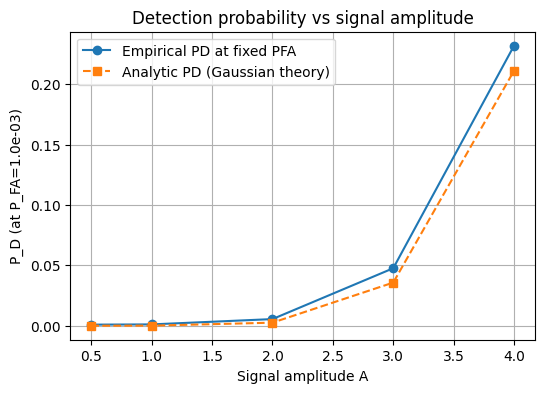

In [38]:
# Plot PD vs A
plt.figure(figsize=(6,4))
plt.plot(amps_to_plot, PD_emp, 'o-', label="Empirical PD at fixed PFA")
plt.plot(amps_to_plot, PD_theory, 's--', label="Analytic PD (Gaussian theory)")
plt.xlabel("Signal amplitude A")
plt.ylabel(f"P_D (at P_FA={PFA_target:.1e})")
plt.title("Detection probability vs signal amplitude")
plt.grid(True)
plt.legend()
plt.show()

### Discussion

* **ROC interpretation:** The ROC curve plots detection probability $(P_D)$ vs false-alarm probability $(P_{FA})$ as threshold varies, showing the tradeoff between sensitivity (high $(P_D)$) and reliability (low $(P_{FA})$). A curve closer to the upper-left corner is better.
* **Empirical vs analytic:** When the template is normalized and noise is Gaussian, the analytic ROC (derived from normal distributions for $(\rho)$ should match the empirical ROC closely. Small discrepancies arise from finite sample effects, search over time (we used max over many correlated SNR samples), and template/window edge effects.
* **Effect of amplitude (A):** Larger (A) shifts the $(H_1)$ SNR distribution to the right (higher mean), improving $(P_D)$ at fixed $(P_{FA})$.
* **Effect of data length:** Increasing data length increases the number of independent matched-filter samples in each trial, thus the *maximum* over noise-only trials tends to be larger (higher false-alarm excursions) — increasing the threshold required for the same $(P_{FA})$. This may reduce detection probability for fixed (A) unless you compensate by increasing (A) $(SNR)$.
* **Effect of noise level $(\sigma)$:** Increasing noise std reduces $(\mu = A/\sigma)$, decreasing detection probability at fixed threshold. Analytic PD curves scale with $SNR$ $(A/\sigma)$.
* **Matched-filter optimality:** In Gaussian noise the matched filter is the optimal linear detector for maximizing $SNR$ and thus it gives the best possible ROC among linear detectors — that's why analytic ROC is the performance bound for such detectors.


---